# Sesión 7: Forecasting con LSTM Puro (sin TDA)

## Objetivo
Implementar un LSTM que ingiere **únicamente la serie de tiempo de precios** (sin características topológicas) con la misma arquitectura que Sesión 6. El propósito es aislar la contribución del TDA: si LSTM+TDA supera a LSTM-puro, la mejora se debe a las características topológicas.

**Fuente de datos:** WPUSI01102B.csv  
**Periodo:** Jun 2008 – Abr 2026 (215 puntos mensuales)  
**Input:** `(batch, 12, 1)` — 12 pasos temporales, 1 característica (precio) en lugar de 152

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)
print(f"TensorFlow {tf.__version__}")

TensorFlow 2.21.0


In [2]:
df     = pd.read_csv('WPUSI01102B.csv', parse_dates=['observation_date'])
prices = df['WPUSI01102B'].values.astype(float)
dates  = df['observation_date'].values
print(f"Total samples: {len(prices)}  ({dates[0]} → {dates[-1]})")

# Start at W-1=35 to align test set with Sesion-6 (same 168 sequences)
W      = 36   # Sesion-6 rolling window — used only for alignment
L      = 12   # LSTM lookback
OFFSET = W - 1

prices_sub = prices[OFFSET:]   # 180 values
dates_sub  = dates[OFFSET:]
print(f"Sub-series length: {len(prices_sub)}")

Total samples: 215  (2008-06-01T00:00:00.000000 → 2026-04-01T00:00:00.000000)
Sub-series length: 180


## 1. Construcción de Secuencias

Ventana deslizante de longitud `L=12` sobre la serie de precios.  
`X[i] = prices[i:i+L]` reshaped a `(12, 1)`, `y[i] = prices[i+L]`.

In [3]:
X_list, y_list = [], []
for i in range(len(prices_sub) - L):
    X_list.append(prices_sub[i : i + L])
    y_list.append(prices_sub[i + L])

X = np.array(X_list).reshape(-1, L, 1)   # (168, 12, 1)
y = np.array(y_list)                      # (168,)
print(f"X: {X.shape},  y: {y.shape}")
print(f"y range: [{y.min():.1f}, {y.max():.1f}]")

X: (168, 12, 1),  y: (168,)
y range: [69.2, 299.4]


## 2. División Cronológica y Normalización

70% train / 15% val / 15% test — mismas proporciones que Sesión 6.  
Con 168 secuencias: `int(168×0.70)=117`, `int(168×0.15)=25`, test=26.  
El conjunto de prueba cubre exactamente el mismo periodo que Sesión 6 → comparación directa válida.

In [4]:
n       = len(X)
n_train = int(n * 0.70)   # 117
n_val   = int(n * 0.15)   # 25

X_train, y_train = X[:n_train],               y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val],  y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],         y[n_train+n_val:]

print(f"Train: {len(X_train)},  Val: {len(X_val)},  Test: {len(X_test)}")

# Fit scalers on train only
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(
    X_train.reshape(-1, 1)).reshape(X_train.shape)
X_val_s   = scaler_X.transform(
    X_val.reshape(-1, 1)).reshape(X_val.shape)
X_test_s  = scaler_X.transform(
    X_test.reshape(-1, 1)).reshape(X_test.shape)

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_s   = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
print("Scalers fit on train only ✓")

Train: 117,  Val: 25,  Test: 26
Scalers fit on train only ✓


## 3. Arquitectura LSTM Puro

Misma arquitectura que Sesión 6: `LSTM(64) → LSTM(32) → Dense(16) → Dense(1)`.  
Única diferencia: `input_shape=(12, 1)` en lugar de `(12, 152)` — 55 552 parámetros vs 3 969 parámetros.

In [5]:
model = Sequential([
    LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1,
         input_shape=(L, 1)),
    LSTM(32, dropout=0.2, recurrent_dropout=0.1),
    Dense(16, activation='relu'),
    Dense(1)
], name="LSTM_Pure")

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mae', metrics=['mse'])
model.summary()

Model: "LSTM_Pure"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=20,
                           restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)
print(f"Stopped at epoch {len(history.history['loss'])}")

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.7996 - mse: 1.0025 - val_loss: 0.8560 - val_mse: 1.2446
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7905 - mse: 1.0021 - val_loss: 0.8600 - val_mse: 1.2607
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7813 - mse: 0.9975 - val_loss: 0.8610 - val_mse: 1.2686
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7725 - mse: 0.9963 - val_loss: 0.8659 - val_mse: 1.2825
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7559 - mse: 0.9756 - val_loss: 0.8642 - val_mse: 1.2794
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7426 - mse: 0.9562 - val_loss: 0.8585 - val_mse: 1.2597
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6958 - mse: 0.8924 - val_loss: 0.8275 - val_mse: 1.1724
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6824 - mse: 0.8576 - val_loss: 0.8090 - val_mse: 1.1023
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6675 - mse: 0.8259 

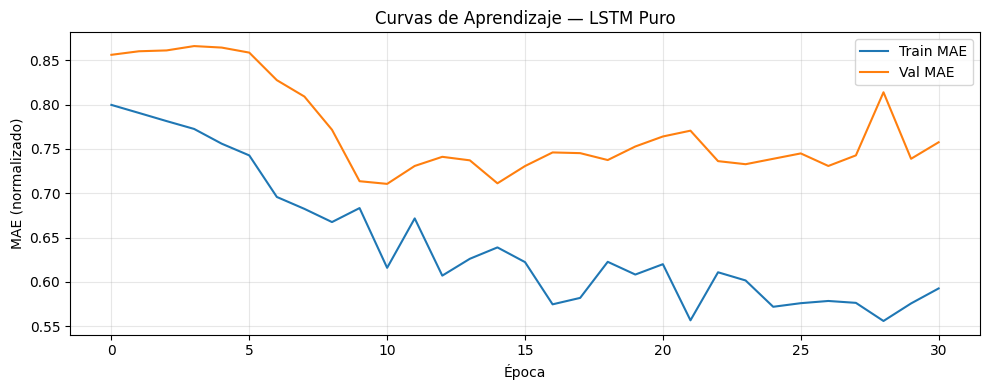

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train MAE')
ax.plot(history.history['val_loss'], label='Val MAE')
ax.set_xlabel('Época')
ax.set_ylabel('MAE (normalizado)')
ax.set_title('Curvas de Aprendizaje — LSTM Puro')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Evaluación

In [8]:
y_pred_s = model.predict(X_test_s).flatten()
y_pred   = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()

pure_mae  = mean_absolute_error(y_test, y_pred)
pure_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
pure_r2   = r2_score(y_test, y_pred)

print("── LSTM Puro (test set) ──────────────────────────────")
print(f"  MAE  : {pure_mae:.4f}")
print(f"  RMSE : {pure_rmse:.4f}")
print(f"  R²   : {pure_r2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
── LSTM Puro (test set) ──────────────────────────────
  MAE  : 33.4366
  RMSE : 44.8407
  R²   : 0.3834


## 6. Comparación de Modelos

Resultados de Sesión 6 copiados directamente (mismo conjunto de prueba).  
La diferencia entre LSTM+TDA y LSTM-puro aisla el aporte de las características topológicas.

In [9]:
# Results from Sesion-6 (same test set)
results = pd.DataFrame({
    'Modelo': ['RandomForest (baseline)', 'LSTM + TDA (Sesión 6)', 'LSTM Puro (Sesión 7)'],
    'MAE':    [38.7105,   29.4890,   pure_mae],
    'RMSE':   [48.9645,   37.5017,   pure_rmse],
    'R²':     [0.2647,    0.5687,    pure_r2],
    'Features/paso': [1824, 152, 1],
})
results = results.set_index('Modelo')

print("\n" + "="*65)
print("   COMPARACIÓN DE MODELOS — Conjunto de Prueba")
print("="*65)
print(results.round(4).to_string())
print("="*65)


   COMPARACIÓN DE MODELOS — Conjunto de Prueba
                             MAE     RMSE      R²  Features/paso
Modelo                                                          
RandomForest (baseline)  38.7105  48.9645  0.2647           1824
LSTM + TDA (Sesión 6)    29.4890  37.5017  0.5687            152
LSTM Puro (Sesión 7)     33.4366  44.8407  0.3834              1


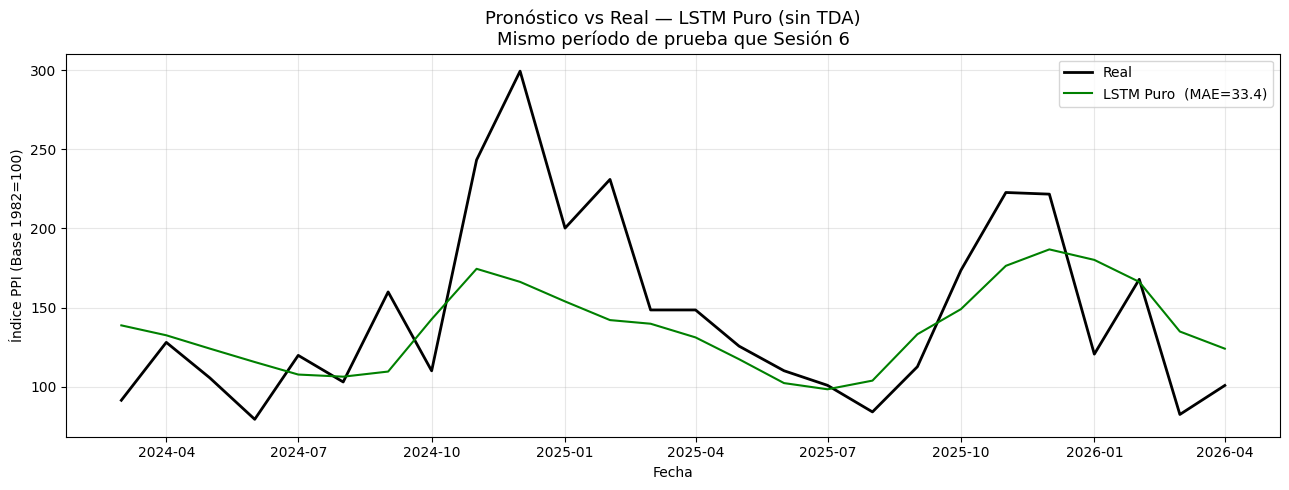

In [10]:
# Test dates: same period as Sesion-6
test_start_t  = OFFSET + n_train + n_val + L   # = 35 + 117 + 25 + 12 = 189
test_dates_plot = dates[test_start_t : test_start_t + len(y_test)]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates_plot, y_test,  'k-',  linewidth=2,   label='Real')
ax.plot(test_dates_plot, y_pred,  'g-',  linewidth=1.5, label=f'LSTM Puro  (MAE={pure_mae:.1f})')
ax.set_xlabel('Fecha')
ax.set_ylabel('Índice PPI (Base 1982=100)')
ax.set_title('Pronóstico vs Real — LSTM Puro (sin TDA)\nMismo período de prueba que Sesión 6', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Preguntas de Análisis

1. **¿El TDA agrega valor?** Compara LSTM-puro vs LSTM+TDA. ¿La diferencia en MAE justifica la complejidad computacional del TDA (extracción de características ~180 ventanas)?

2. **Parámetros vs desempeño:** LSTM-puro tiene ~3 969 parámetros; LSTM+TDA tiene ~68 513. ¿Cómo se relaciona esta diferencia con la capacidad de aprendizaje en un conjunto de 117 muestras de entrenamiento?

3. **Curvas de aprendizaje:** ¿El LSTM-puro converge más rápido que LSTM+TDA (menos épocas)? ¿Qué sugiere esto sobre la dificultad del problema de optimización con 1 vs 152 features?

4. **Efecto de normalización:** Con solo 1 feature por paso temporal, el `StandardScaler` aplica una sola transformación lineal a toda la serie. ¿Por qué esto es equivalente a normalizar manualmente con la media y desviación estándar del conjunto de entrenamiento?

5. **Límites del LSTM puro:** Si la serie tuviera estacionalidad anual fuerte, ¿sería suficiente `L=12` para capturarla? ¿Qué ventaja tendría el embedding de Takens sobre una ventana cruda de precios para detectar ciclos?